In [1]:
from lcg_plus.optimizer import GBS_optimizer
from lcg_plus.cost_functions import symm_effective_squeezing_gradients, symm_effective_squeezing_squared_gradients, gkp_squeezing_gradients
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import seaborn as sns


In [2]:
def get_slope(diffs, deltas, mask):
    
    fit = np.polyfit(np.log10(deltas[mask]),
                    np.log10(diffs[mask]), 1)
    return fit

def very_gradients_using_finite_differences(seed, opt, deltas = 10**np.linspace(-7,0), mask = None, plot_title='a)'):

    np.random.seed(seed)
    opt.set_initial_guess()

    cmap = sns.color_palette('tab10',as_cmap =True)
    c = cmap(np.linspace(0, 1, opt.num_params))

    eff0, grad0 = opt.init_costf

    print(eff0, grad0)
    params_init = opt.guess

    if not mask:
        mask = (deltas > 1e-3) & (deltas < 1e-1)

    for i in range(len(grad0)):
        diffs = np.zeros(len(deltas))
        for j, dx in enumerate(deltas): 
            params_plus = deepcopy(params_init)
            params_minus = deepcopy(params_init)
            #Perturb one parameter with dx
            params_plus[i] += dx
            params_minus[i] -= dx
            
            eff_plus, grad_plus = opt.costf(params_plus, *opt.costf_args)
            eff_minus, grad_minus = opt.costf(params_minus, *opt.costf_args)

            diffs[j] = np.abs(grad0[i]-(eff_plus-eff_minus)/(2*dx)) #The central difference
            
        plt.plot(deltas, diffs, color = c[i], label =  f'parameter {i}', linestyle = '', marker= 'o')
        
        coef  = get_slope(diffs, deltas, mask)
        print(f'Slope for parameter {i}', coef[0]) #Slope should be 2

    plt.plot(deltas, deltas**2, label = r'$\delta x^2$',linestyle='dashed',color='k')
    plt.ylim([1e-9,10])
    plt.grid('on')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r'$|\nabla f - (f-f_0)/\delta_x|$')
    plt.xlabel(r'$\delta_x$')
    plt.legend()
    plt.title(plot_title, loc = 'left')
    plt.show()



## Verifying gradients of effective squeezing with finite differences

1.125729956852743 [ 1.02644375  0.4153731  -1.0137155   1.29019314  0.36832288  0.98720873]
Slope for parameter 0 2.0632755489255215
Slope for parameter 1 1.9893076278194586
Slope for parameter 2 2.1160459098613713
Slope for parameter 3 2.1283780992554213
Slope for parameter 4 2.0110572749940596
Slope for parameter 5 2.0681127903698067


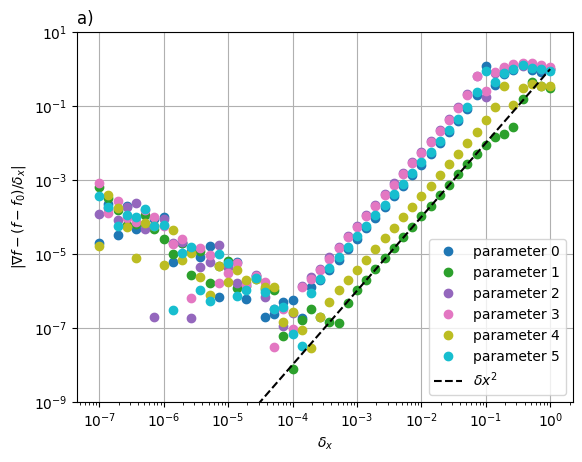

In [3]:
seed = 120
opt = GBS_optimizer(3,
                    pattern = [5,5], 
                    inf = 1e-4, 
                    bs_arrange='Clements', 
                    gradients = True, etas = np.array([0.9,0.7,1]),
                    costf = symm_effective_squeezing_gradients)

very_gradients_using_finite_differences(seed, opt)




1.420330595752141 [ 3.22018892  1.59431948 -2.89297384  4.13003201  0.98828623  3.04038645]
Slope for parameter 0 2.0647666782484344
Slope for parameter 1 1.9877821571080216
Slope for parameter 2 2.124308461740654
Slope for parameter 3 2.1321365477869496
Slope for parameter 4 2.012482766858627
Slope for parameter 5 2.0705689353106473


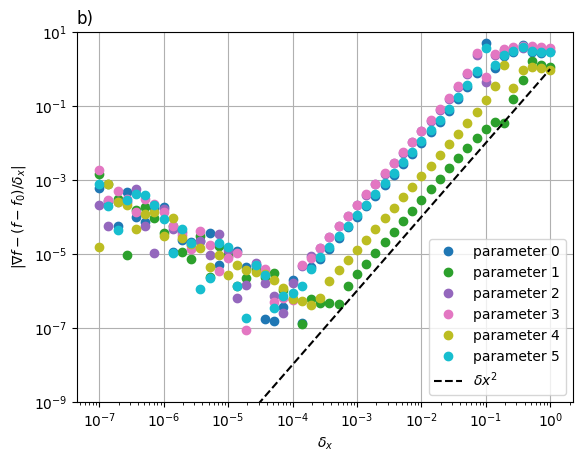

In [4]:
seed = 120
opt = GBS_optimizer(3,
                    pattern = [5,5], 
                    inf = 1e-4, 
                    bs_arrange='Clements', 
                    gradients = True, etas = np.array([0.9,0.7,1]),
                    costf = symm_effective_squeezing_squared_gradients)

very_gradients_using_finite_differences(seed, opt, plot_title='b)')



## Verifying gradients of gkp squeezing with with finite differences

1.5082236124872057 [-0.21215176 -0.28051153  0.05726921 -0.36450449  0.04347831 -0.19765676]
Slope for parameter 0 1.9995607531119808
Slope for parameter 1 2.028108756801771
Slope for parameter 2 1.9882735096345312
Slope for parameter 3 1.9984842808335763
Slope for parameter 4 2.003364586139528
Slope for parameter 5 2.001500262662375


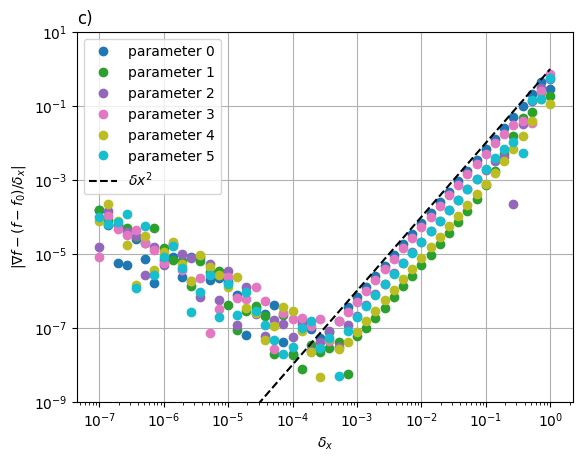

In [5]:
opt = GBS_optimizer(3,
                    pattern = [5,5], 
                    inf = 1e-4, 
                    bs_arrange='Clements', 
                    gradients = True,
                    costf_lattice = 's0',
                    costf = gkp_squeezing_gradients)

very_gradients_using_finite_differences(seed, opt, plot_title='c)')
